In [193]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Data splitting
from sklearn.model_selection import train_test_split

# Pipeline
from sklearn.pipeline import Pipeline


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    average_precision_score,
    confusion_matrix
)

# Optional: XGBoost
from xgboost import XGBClassifier
import joblib


In [2]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = "creditcard.csv"          # update path for a different dataset
TARGET_COL = "Class" # target column name

In [3]:
df=pd.read_csv(CSV_PATH)

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,0.000,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,1.000,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0
3,1.000,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
4,2.000,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0


In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
df.shape

(284807, 31)

In [8]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:",
      duplicate_count / len(df) * 100)

Duplicate rows: 1081
Duplicate percentage: 0.379555277784605


In [104]:
# df.drop_duplicates(inplace=True)

In [9]:
df.shape

(284807, 31)

In [106]:
df.isnull().sum().sum()


np.int64(0)

In [10]:
constant_features = [col for col in df.columns if df[col].nunique() == 1]

print("Constant Features:", constant_features)
print("Number of Constant Features:", len(constant_features))

threshold = 0.95

quasi_constant_features = []

for col in df.columns[:-1]:  # exclude the target column
    top_frequency = df[col].value_counts(normalize=True).iloc[0]
    if top_frequency >= threshold:
        quasi_constant_features.append(col)

print("Quasi-Constant Features:", quasi_constant_features)
print("Number of Quasi-Constant Features:", len(quasi_constant_features))

Constant Features: []
Number of Constant Features: 0
Quasi-Constant Features: []
Number of Quasi-Constant Features: 0


In [11]:
df.nunique()

Time      124592
V1        275663
V2        275663
V3        275663
V4        275663
V5        275663
V6        275663
V7        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V14       275663
V15       275663
V16       275663
V17       275663
V18       275663
V19       275663
V20       275663
V21       275663
V22       275663
V23       275663
V24       275663
V25       275663
V26       275663
V27       275663
V28       275663
Amount     32767
Class          2
dtype: int64

In [12]:
print(df[TARGET_COL].value_counts(normalize=True).head(3))  # print top 3 most frequent values



Class
0   0.998
1   0.002
Name: proportion, dtype: float64


### Class Distribution

The target variable is **highly imbalanced**:

- **Class 0 (Legitimate Transactions):** 99.8%
- **Class 1 (Fraudulent Transactions):** 0.2%

**Important:** Due to this severe class imbalance, **accuracy alone would be misleading**. A model could achieve very high accuracy simply by predicting most transactions as legitimate.

Therefore, model evaluation should focus on:

- **Precision**
- **Recall**
- **F1-score**
- **PR-AUC**
- **Confusion Matrix**

Special attention should be given to **Recall for Class 1**, since the main objective is to correctly identify fraudulent transactions and minimize false negatives.

In [14]:
df[['Time','Amount']].describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.000,94813.860,47488.146,0.000,54201.500,84692.000,139320.500,172792.000
Amount,284807.000,88.350,250.120,0.000,5.600,22.000,77.165,25691.160


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [16]:
print("Negative Amount:", (df["Amount"] < 0).sum())
print("Negative Time:", (df["Time"] < 0).sum())

Negative Amount: 0
Negative Time: 0


In [18]:
print(df[['Time', 'Amount']].skew())


Time     -0.036
Amount   16.978
dtype: float64


### Skewness Analysis

Skewness was calculated to evaluate the symmetry of the numerical feature distributions.

- `Time` has a skewness of approximately **-0.036**, indicating that its distribution is nearly symmetric.
- Several PCA-transformed features (`V1–V28`) show noticeable skewness in both directions. For example, `V8` has a strong negative skewness (`-8.311`), while `V28` has a strong positive skewness (`11.555`). These values indicate asymmetric distributions with longer tails in the corresponding directions.
- `Amount` has a very high positive skewness of **16.979**, indicating a **strong right-skewed distribution**. This is consistent with the large difference between its mean (`88.47`) and median (`22.00`) and its high maximum value (`25,691.16`).
- `Class` has a high skewness (`24.431`), but this is expected because it is a highly imbalanced binary target variable, with approximately **99.8% legitimate transactions and 0.2% fraudulent transactions**. Therefore, skewness analysis is not used to determine preprocessing for the target variable.

Overall, the skewness results indicate that `Amount` has a particularly strong asymmetric distribution and should be investigated further using visualization and outlier analysis before deciding whether any transformation is necessary.

In [19]:
target_corr = df.corr()["Class"].drop("Class").sort_values()

target_corr

V17      -0.326
V14      -0.303
V12      -0.261
V10      -0.217
V16      -0.197
V3       -0.193
V7       -0.187
V18      -0.111
V1       -0.101
V9       -0.098
V5       -0.095
V6       -0.044
Time     -0.012
V24      -0.007
V13      -0.005
V15      -0.004
V23      -0.003
V22       0.001
V25       0.003
V26       0.004
Amount    0.006
V28       0.010
V27       0.018
V8        0.020
V20       0.020
V19       0.035
V21       0.040
V2        0.091
V4        0.133
V11       0.155
Name: Class, dtype: float64

In [20]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.000,88.291,250.105,0.000,5.650,22.000,77.050,25691.160
1,492.000,122.211,256.683,0.000,1.000,9.250,105.890,2125.870


In [22]:
plot_columns = ['Time','Amount']

n_cols = 5
n_rows = math.ceil(len(plot_columns) / n_cols)

e:\New folder\menna ahmed khamis\after iti\Ai\Jupyter_lab\projects\5-Credit_card_fraud_detection\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


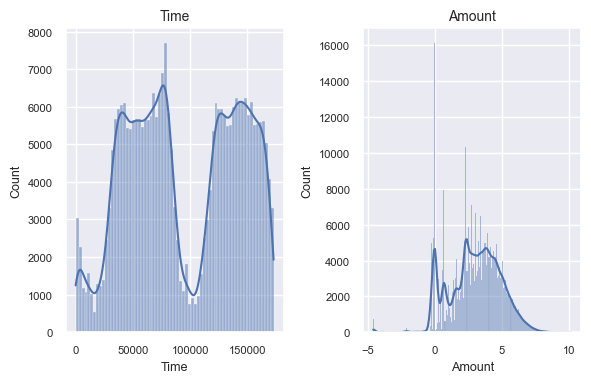

In [27]:

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_columns):
    if col=='Time':
         sns.histplot(df[col], kde=True, ax=axes[i])
    else:
        sns.histplot(np.log(df[col]), kde=True, ax=axes[i])

    axes[i].set_title(col)

for j in range(len(plot_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

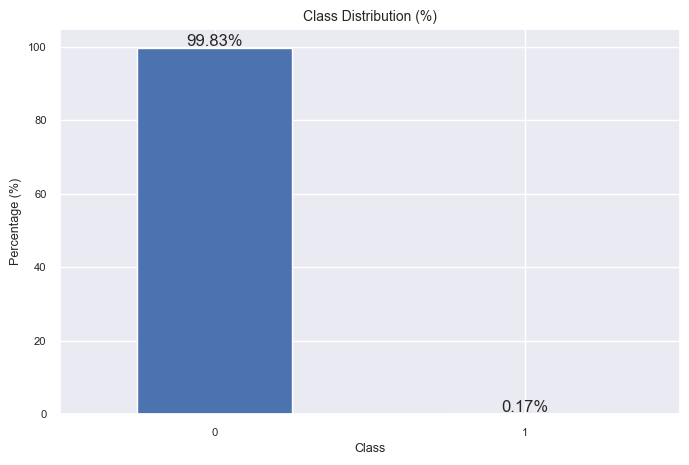

In [28]:
class_proportion = df["Class"].value_counts(normalize=True) * 100

ax = class_proportion.plot(kind="bar", figsize=(8, 5))

plt.title("Class Distribution (%)")
plt.xlabel("Class")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

for i, value in enumerate(class_proportion):
    ax.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.show()

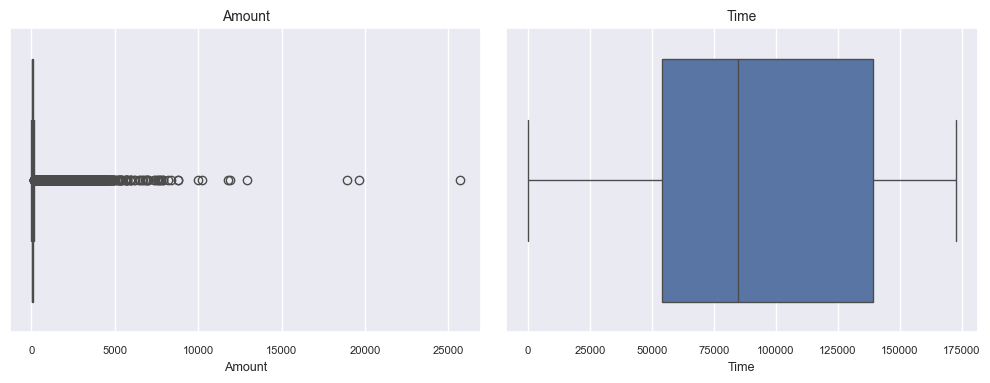

In [29]:
plot_columns = ["Amount", "Time"]  # Use all columns for boxplots

n_cols = 3
n_rows = math.ceil(len(plot_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)

# Remove unused axes
for j in range(len(plot_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

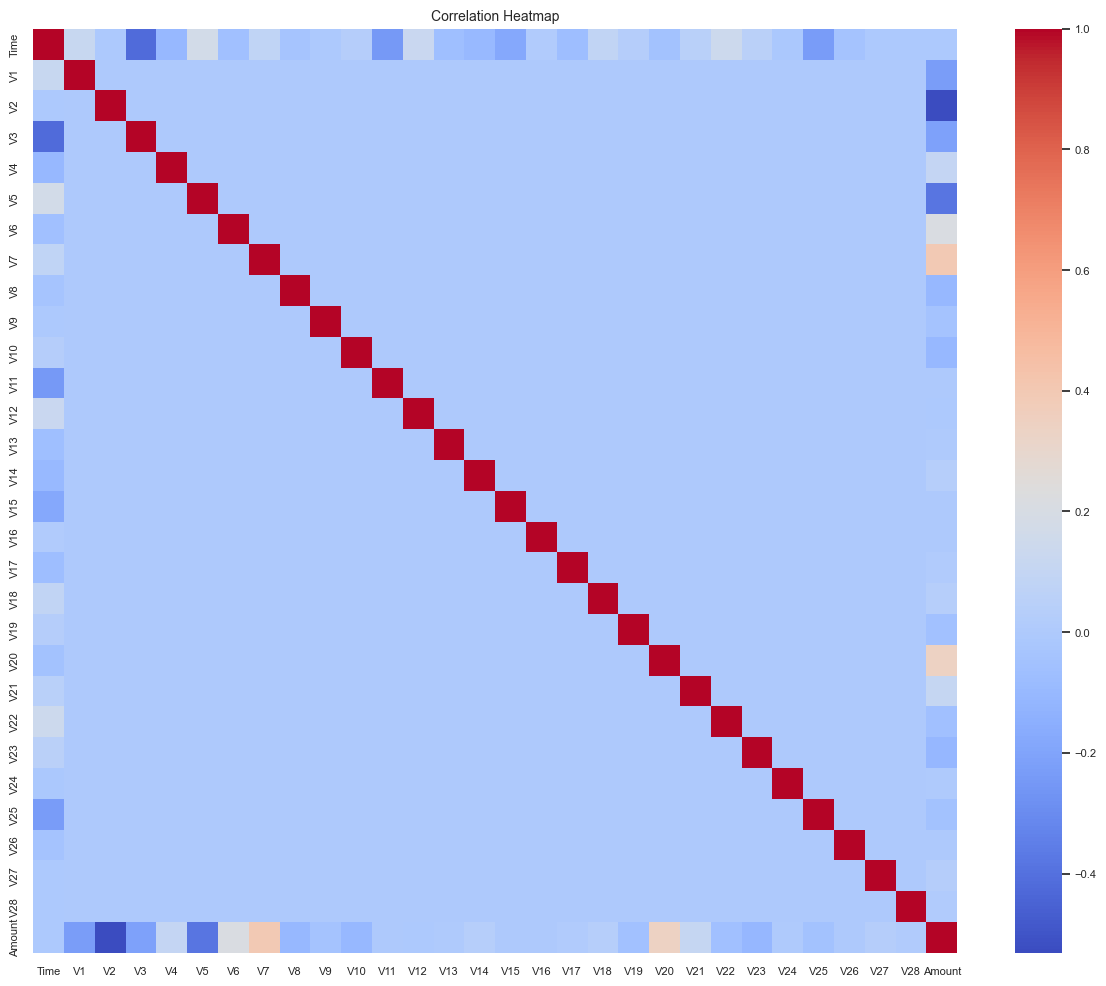

In [30]:
plt.figure(figsize=(15, 12))

sns.heatmap(
    df.iloc[:, :-1].corr(),  
    cmap="coolwarm",
    annot=False,              
    square=True
)

plt.title("Correlation Heatmap")
plt.show()

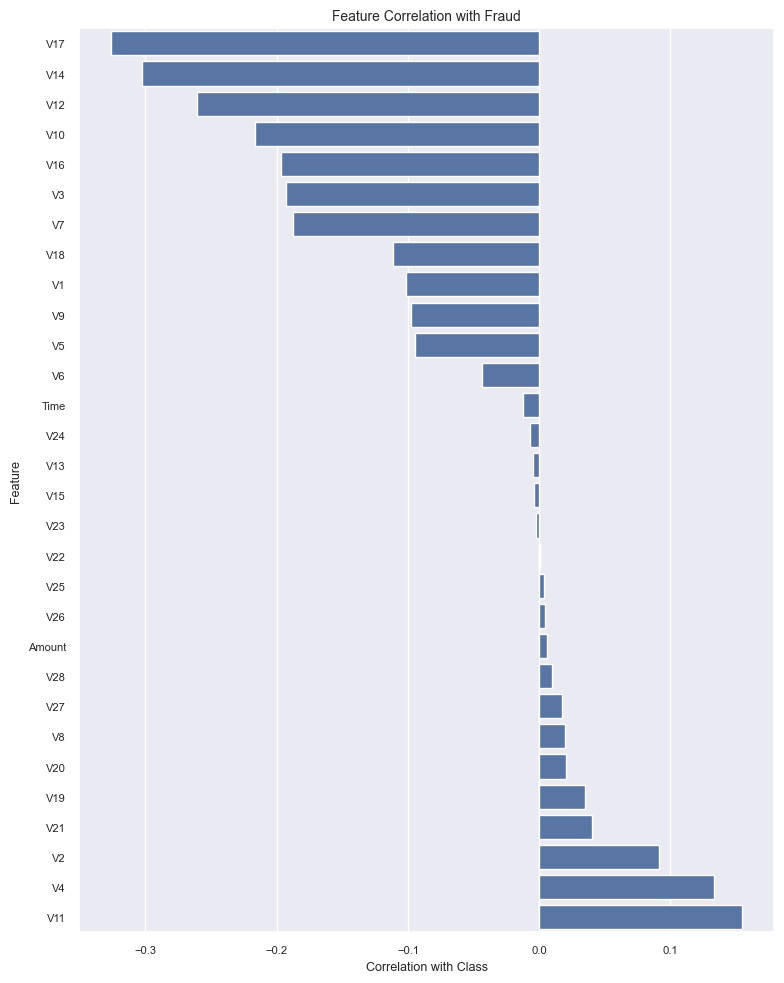

In [31]:
target_corr = df.corr()["Class"].drop("Class").sort_values()

plt.figure(figsize=(8, 10))

sns.barplot(
    x=target_corr.values,
    y=target_corr.index
)

plt.title("Feature Correlation with Fraud")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

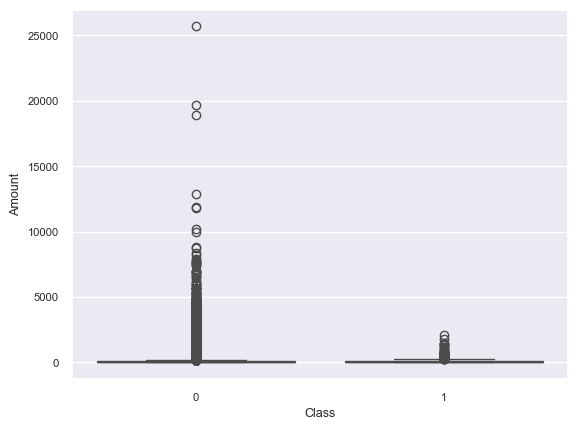

In [32]:
sns.boxplot(data=df, x="Class", y="Amount")
plt.show()

In [33]:
# Features to investigate for outliers
outlier_features = ["Amount", "Time"]

for feature in outlier_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    print(f"\n--- {feature} ---")
    print(f"Q1: {Q1:.3f}")
    print(f"Q3: {Q3:.3f}")
    print(f"IQR: {IQR:.3f}")
    print(f"Lower Bound: {lower_bound:.3f}")
    print(f"Upper Bound: {upper_bound:.3f}")
    print(f"Number of potential outliers: {len(outliers)}")
    print(f"Percentage of potential outliers: {len(outliers) / len(df) * 100:.2f}%")


--- Amount ---
Q1: 5.600
Q3: 77.165
IQR: 71.565
Lower Bound: -101.748
Upper Bound: 184.512
Number of potential outliers: 31904
Percentage of potential outliers: 11.20%

--- Time ---
Q1: 54201.500
Q3: 139320.500
IQR: 85119.000
Lower Bound: -73477.000
Upper Bound: 266999.000
Number of potential outliers: 0
Percentage of potential outliers: 0.00%


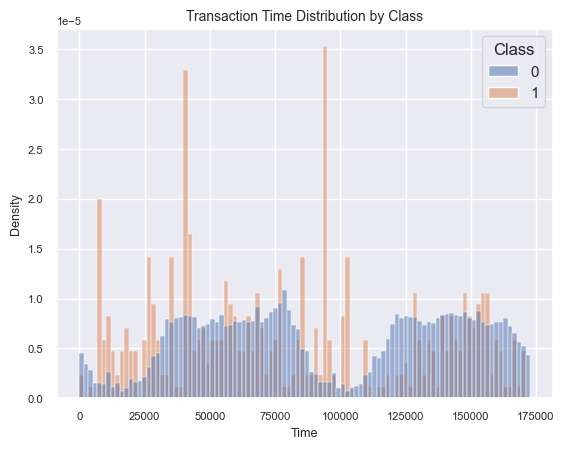

In [34]:
sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=100,
    stat="density",
    common_norm=False
)

plt.title("Transaction Time Distribution by Class")
plt.show()

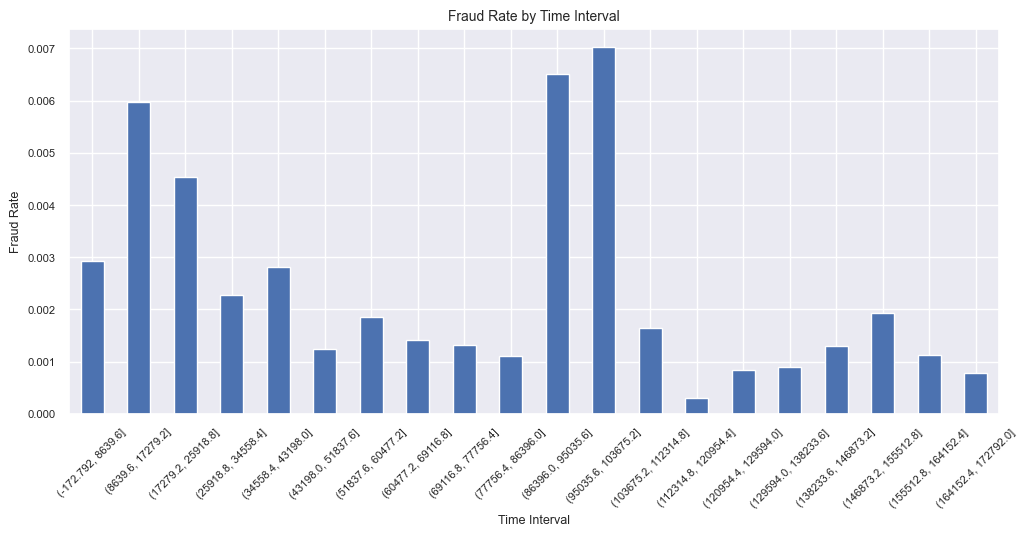

In [35]:
df["TimeBin"] = pd.cut(df["Time"], bins=20)

fraud_rate = df.groupby("TimeBin", observed=True)["Class"].mean()

fraud_rate.plot(kind="bar", figsize=(12, 5))

plt.ylabel("Fraud Rate")
plt.xlabel("Time Interval")
plt.title("Fraud Rate by Time Interval")
plt.xticks(rotation=45)
plt.show()

### Time Distribution and Fraud Rate by Time Interval

- The distribution of `Time` differs between legitimate and fraudulent transactions.
- Fraudulent transactions are more concentrated within certain time intervals.
- The calculated fraud rate also varies across time intervals, with some intervals showing noticeably higher fraud rates than others.
- This suggests that `Time` may contain useful information for distinguishing between fraudulent and legitimate transactions.
- However, these patterns indicate an association rather than causation; higher fraud rates in certain intervals do not mean that the time period itself causes fraud.


## EDA Summary

The dataset is generally clean, with no missing values or invalid
negative values. Duplicate records were removed.

The target variable is highly imbalanced, with fraudulent transactions
representing only a very small proportion of the dataset. Therefore,
accuracy alone should not be relied upon during model evaluation.

`Amount` is strongly right-skewed and contains potential extreme values.
These observations were retained because they may represent valid
transactions and potentially provide useful information for fraud
detection.

The PCA-transformed features (`V1–V28`) show different distribution
shapes and levels of skewness but do not have direct business
interpretations.

`Time` shows different distributions between legitimate and fraudulent
transactions, and fraud rates vary across time intervals. This suggests
that `Time` may contain useful predictive information, although the
observed patterns represent association rather than causation.

Overall, the dataset is suitable for proceeding to the preprocessing
stage.

In [67]:
df['Amount_log']=np.log1p(df['Amount'])

In [68]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,TimeBin,Amount_log
0,0.000,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0,"(-172.792, 8639.6]",5.015
1,0.000,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0,"(-172.792, 8639.6]",1.306
2,1.000,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0,"(-172.792, 8639.6]",5.939
3,1.000,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0,"(-172.792, 8639.6]",4.824
4,2.000,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0,"(-172.792, 8639.6]",4.263


In [70]:
y=df[TARGET_COL]
x=df.drop(columns=[TARGET_COL, "TimeBin",'Amount'])  # Exclude the target, Amount and TimeBin columns

In [71]:
x.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log'],
      dtype='object')

In [72]:
x_train ,x_test ,y_train ,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [73]:
df.shape

(284807, 33)

In [74]:
x_train.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log'],
      dtype='object')

In [75]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((227845, 30), (56962, 30), (227845,), (56962,))

In [76]:
y_train.value_counts(normalize=True)

Class
0   0.998
1   0.002
Name: proportion, dtype: float64

In [77]:
y_test.value_counts(normalize=True)

Class
0   0.998
1   0.002
Name: proportion, dtype: float64

In [78]:
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=RANDOM_STATE , max_iter=1000))
])

In [79]:
np.isinf(x_train).sum().sum()

np.int64(0)

In [80]:
baseline.fit(x_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [46]:
base_train_pred=baseline.predict(x_train)

In [47]:
print(classification_report(
    y_train,
    base_train_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       0.88      0.63      0.73       394

    accuracy                           1.00    227845
   macro avg       0.94      0.81      0.87    227845
weighted avg       1.00      1.00      1.00    227845



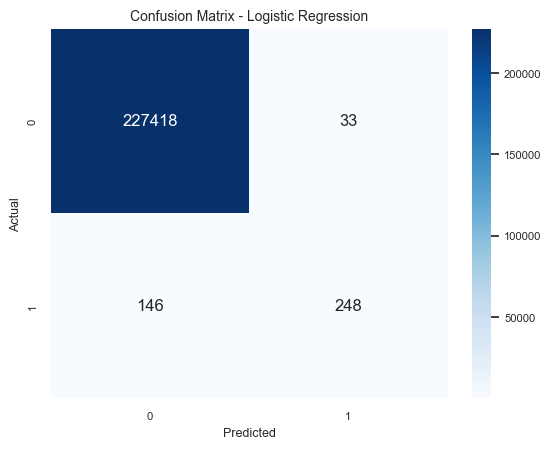

In [81]:
cm = confusion_matrix(y_train, base_train_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [82]:
train_accuracy = accuracy_score(
    y_train,
    base_train_pred
)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.9992143781957032


In [83]:
base_test_pred=baseline.predict(x_test)

In [84]:
test_accuracy = accuracy_score(
    y_test,
    base_test_pred
)

print("test Accuracy:", test_accuracy)

test Accuracy: 0.9991748885221726


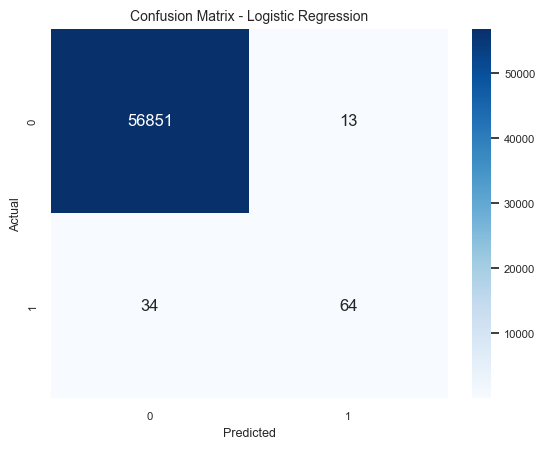

In [85]:
cm = confusion_matrix(y_test, base_test_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [86]:
print(classification_report(
    y_test,
    base_test_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962



### Baseline Model Report

**Model:** Decision Tree Classifier

The Decision Tree was used as the baseline model for the Credit Card Fraud Detection task. The model achieved very high performance on the majority class (legitimate transactions), with **1.00 precision, recall, and F1-score**.

For the minority **fraud class (Class 1)**, the model achieved:

* **Precision:** 0.83
* **Recall:** 0.65
* **F1-score:** 0.73

Although the overall accuracy was approximately **1.00**, accuracy is not considered a reliable metric because the dataset is **highly imbalanced**. Therefore, greater attention is given to the fraud-class metrics.

The baseline successfully identifies a significant portion of fraudulent transactions, but its **65% recall** indicates that some fraud cases are still being missed. This provides a useful reference point for evaluating more advanced models such as **Random Forest and XGBoost**.


In [88]:
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000,
            class_weight="balanced"
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
        
    ),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="aucpr"
    )
}

In [89]:
k=5
cv=StratifiedKFold(n_splits=k, shuffle=True,random_state=RANDOM_STATE)

In [93]:
results = []

for name, model in models.items():

    # Cross-validation
    cv_results = cross_validate(
        model,
        x_train,
        y_train,
        cv=cv,
        scoring={
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "pr_auc": "average_precision"
        },
        n_jobs=-1
    )

    # Fit on full training set
    model.fit(x_train, y_train)

    # Test prediction
    y_pred = model.predict(x_test)

    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    # Test PR-AUC
    y_proba = model.predict_proba(x_test)[:, 1]
    pr_auc = average_precision_score(y_test, y_proba)

    results.append({
        "Model": name,

        # CV
        "CV Precision": cv_results["test_precision"].mean(),
        "CV Recall": cv_results["test_recall"].mean(),
        "CV F1": cv_results["test_f1"].mean(),
        "CV PR-AUC": cv_results["test_pr_auc"].mean(),

        # Test
        "Test Precision": precision,
        "Test Recall": recall,
        "Test F1": f1,
        "Test PR-AUC": pr_auc
    })

results = sorted(
    results,
    key=lambda x: x["CV PR-AUC"],
    reverse=True
)

for result in results:
    print(result)

{'Model': 'Random Forest', 'CV Precision': np.float64(0.9520659907032858), 'CV Recall': np.float64(0.741123012009088), 'CV F1': np.float64(0.8328034474598602), 'CV PR-AUC': np.float64(0.8393862981954104), 'Test Precision': 0.9605263157894737, 'Test Recall': 0.7448979591836735, 'Test F1': 0.8390804597701149, 'Test PR-AUC': 0.8543347398579655}
{'Model': 'Logistic Regression', 'CV Precision': np.float64(0.061279336075020764), 'CV Recall': np.float64(0.9086984745212593), 'CV F1': np.float64(0.11477602448205668), 'CV PR-AUC': np.float64(0.7583251133830642), 'Test Precision': 0.06028131279303416, 'Test Recall': 0.9183673469387755, 'Test F1': 0.11313639220615965, 'Test PR-AUC': 0.711313889326532}
{'Model': 'XGBoost', 'CV Precision': np.float64(0.7254251179532079), 'CV Recall': np.float64(0.6127231418370658), 'CV F1': np.float64(0.6623221397875401), 'CV PR-AUC': np.float64(0.612429292492066), 'Test Precision': 0.8666666666666667, 'Test Recall': 0.7959183673469388, 'Test F1': 0.8297872340425532

### Baseline Evaluation

Models were evaluated using **5-fold Stratified Cross-Validation** with focus on **PR-AUC, Precision, Recall, and F1-score** due to the highly imbalanced dataset.

* **Random Forest** achieved the best overall performance (**CV PR-AUC = 0.839, F1 = 0.833**).
* **Logistic Regression** had the highest Recall (0.909) but very low Precision (0.061).
* **XGBoost** showed lower CV performance (**PR-AUC = 0.612**).

**Conclusion:** Random Forest was selected as the best candidate for **hyperparameter tuning**.


In [94]:
param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5]
}

In [96]:
rf=RandomForestClassifier(
    random_state=42,
    class_weight="balanced"

    )

In [ ]:
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

In [98]:
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 5, ...], 'n_estimators': [200, 300, ...]}"
,n_iter,10
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV :")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Best CV Recall:
0.8423533009281844


In [102]:
best_rfc = Pipeline(
    [
        ("model", RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=1,
            max_features="log2",
            max_depth=None,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]
)

In [103]:
# train best rfc
best_rfc.fit(x_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'


In [104]:
# training data prediction
y_train_pred = best_rfc.predict(x_train)

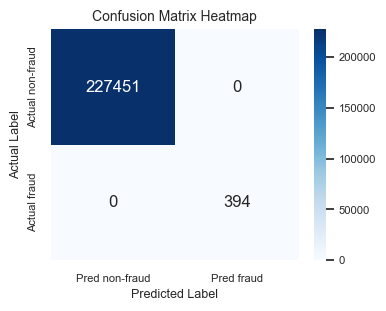

In [105]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(4,3))
# heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred non-fraud", "Pred fraud"],
    yticklabels=["Actual non-fraud", "Actual fraud"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [107]:
# training data prediction
y_test_pred = best_rfc.predict(x_test)

[[56861     3]
 [   23    75]]


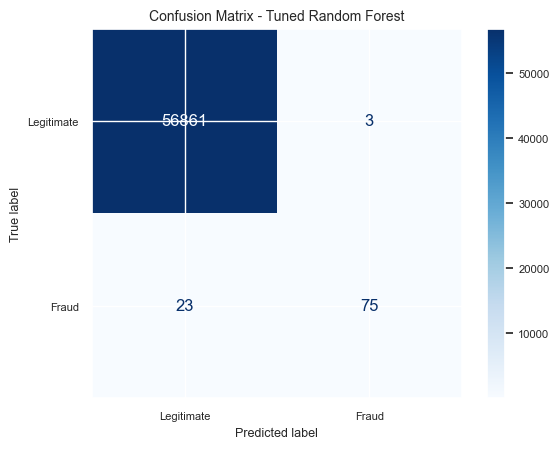

In [108]:
best_rf = random_search.best_estimator_

# y_pred = best_rf.predict(x_test)

cm = confusion_matrix(y_test, y_test_pred)

print(cm)

disp = ConfusionMatrixDisplay( 
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

In [122]:
x_train_model, x_val, y_train_model, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [123]:
best_rfc.fit(
    x_train_model,
    y_train_model
)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'


In [126]:
y_val_proba = best_rfc.predict_proba(x_val)[:, 1]

In [133]:
thresholds = np.arange(0.05, 0.51, 0.01)

precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:

    y_val_pred = (y_val_proba >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.05 | Precision: 0.722 | Recall: 0.823 | F1: 0.769
Threshold: 0.060000000000000005 | Precision: 0.765 | Recall: 0.823 | F1: 0.793
Threshold: 0.07 | Precision: 0.765 | Recall: 0.823 | F1: 0.793
Threshold: 0.08000000000000002 | Precision: 0.780 | Recall: 0.810 | F1: 0.795
Threshold: 0.09000000000000001 | Precision: 0.821 | Recall: 0.810 | F1: 0.815
Threshold: 0.1 | Precision: 0.821 | Recall: 0.810 | F1: 0.815
Threshold: 0.11000000000000001 | Precision: 0.816 | Recall: 0.785 | F1: 0.800
Threshold: 0.12000000000000001 | Precision: 0.816 | Recall: 0.785 | F1: 0.800
Threshold: 0.13 | Precision: 0.816 | Recall: 0.785 | F1: 0.800
Threshold: 0.14 | Precision: 0.827 | Recall: 0.785 | F1: 0.805
Threshold: 0.15000000000000002 | Precision: 0.838 | Recall: 0.785 | F1: 0.810
Threshold: 0.16000000000000003 | Precision: 0.838 | Recall: 0.785 | F1: 0.810
Threshold: 0.17000000000000004 | Precision: 0.861 | Recall: 0.785 | F1: 0.821
Threshold: 0.18000000000000005 | Precision: 0.873 | Recall: 0

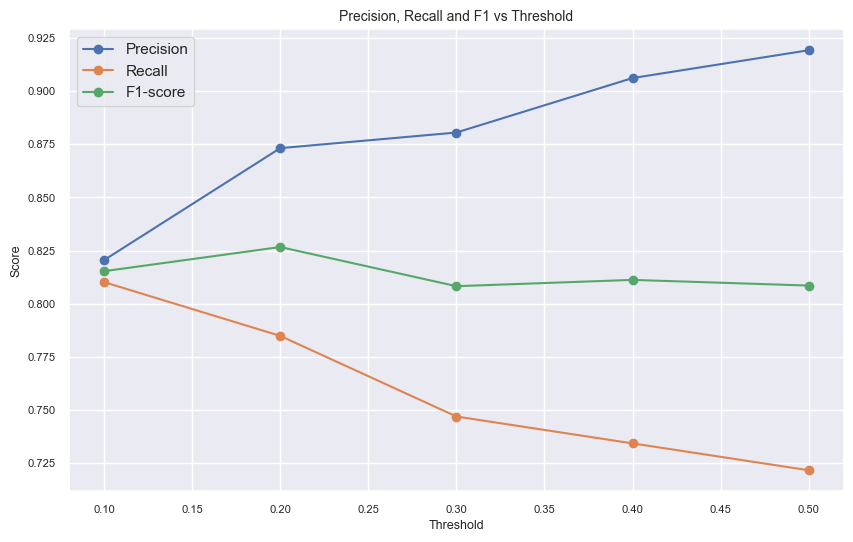

In [118]:
precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:
    y_val_pred = (y_val_proba >= threshold).astype(int)

    precisions.append(precision_score(y_val, y_val_pred))
    recalls.append(recall_score(y_val, y_val_pred))
    f1_scores.append(f1_score(y_val, y_val_pred))

plt.figure(figsize=(10, 6))

plt.plot(thresholds, precisions, marker="o", label="Precision")
plt.plot(thresholds, recalls, marker="o", label="Recall")
plt.plot(thresholds, f1_scores, marker="o", label="F1-score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [162]:
# Best threshold selected from validation
best_threshold = 0.21


# Train best model on ALL training data
best_rfc.fit(x_train, y_train)

# Probability of Fraud
y_test_proba = best_rfc.predict_proba(x_test)[:, 1]

# Apply threshold
y_test_pred = (y_test_proba >= best_threshold).astype(int)

# Final evaluation
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

[[56851    13]
 [   13    85]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.87      0.87        98

    accuracy                           1.00     56962
   macro avg       0.93      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962



Threshold = 0.22 based on the validation set because it achieved the highest F1-score.

In [161]:
pr_auc = average_precision_score(y_test, y_test_proba)
print("PR-AUC:", pr_auc)

PR-AUC: 0.8581848833799368


### Final Threshold Selection

* **Selected threshold:** `0.21`
* **Reason:** It was selected on the validation set because it achieved the highest **F1-score**.
* **Final Test Results:**

  * Precision: **86.7%**
  * Recall: **86.7%**
  * F1-score: **86.7%**
  * PR-AUC: **0.8582**
* **Confusion Matrix:**

  ```text
  [[56851    13]
   [   13    85]]
  ```

> **Threshold = 0.21** provides the best balance between detecting fraudulent transactions and minimizing false positives for this project.


```text
ML Model
   ↓
Save Model (.pkl)
   ↓
FastAPI
   ↓
Prediction API
   ↓
React / Next.js
   ↓
Fraud Detection Dashboard

**9. Build a predictive system**

In [185]:
def predict_class(input_features):
    input_df = pd.DataFrame(
        [input_features],
        columns=x_train.columns
    )

    # Get fraud probability
    proba = best_rfc.predict_proba(input_df)[:, 1]

    # Apply selected threshold
    prediction = (proba >= 0.22).astype(int)

    print("Fraud Probability:", proba[0])
    print("Model prediction:", prediction[0])

    if prediction[0] == 1:
        print("Fraud Transaction detected ❌")
    else:
        print("Non-Fraud Transaction ✅")

In [186]:
y_test.head()

263020    0
11378     0
147283    0
219439    0
36939     0
Name: Class, dtype: int64

In [190]:
y_test[y_test==1].head(10)

77348     1
102442    1
119781    1
48094     1
42958     1
52584     1
204064    1
151519    1
203324    1
141260    1
Name: Class, dtype: int64

In [191]:
test_1 = x_test.loc[151519].tolist()
print(test_1)

[95628.0, -17.5189091261484, 12.5721178535385, -19.0385383213549, 11.1908946558522, -13.5547207079601, -0.41192361337145, -23.189396512394, -5.30141221815132, -8.63039030596902, -16.2556117491401, 5.70211147983179, -13.8124040899594, -0.306815322507812, -7.01360737195925, -1.18229035380557, -9.3601791927531, -16.6683693822389, -7.14746777723207, 2.16209864550609, 2.52851232971436, -4.96947772242457, 0.976124822110751, 1.8412479337881, 0.334417748210128, -0.720128461316563, -0.232603423065217, -3.02199247294556, -0.478158234859683, 0.9669838461896731]


In [192]:
predict_class(test_1)

Fraud Probability: 0.995
Model prediction: 1
Fraud Transaction detected ❌


In [ ]:
joblib.dump(best_rfc, "heart_failure_model1.pkl")


['heart_failure_model1.pkl']

: 